# Descriptive Analysis: A Confederacy of Models

**Dataset:** Gómez-Rodríguez & Williams (2023). *A Confederacy of Models: a Comprehensive Evaluation of LLMs on Creative Writing.* Findings of EMNLP 2023.  
https://github.com/komoku/confederacy-of-models/tree/main  


**Task:** Human evaluation of creative writing by 12 LLMs + 5 human writers on a single prompt  
**Rubric:** 10 dimensions, each scored 1–10 (max total: 100)  
**Design:** 65 stories -> 5 groups × 13 stories, each group rated by 2 independent raters

In [26]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Define rubric labels
RUBRIC_SHORT  = [f'R{i}' for i in range(1, 11)]
RUBRIC_LABELS = ['Readability', 'Narrative elements', 'Structural elements',
                 'Plot logic', 'Creativity', 'Toole style',
                 'Epic genre', 'Combat scene', 'Characters', 'Dark humor']

## Load & parse raw Excel

In [27]:
EXCEL_PATH = 'data/RatersSheet-WithResults.xlsx'

import openpyxl
wb = openpyxl.load_workbook(EXCEL_PATH, read_only=True, data_only=True)
ws = wb["Rater's Sheet Unsorted"]
all_rows = list(ws.iter_rows(min_row=1, max_row=76, values_only=True))

# Model names
MODEL_NAMES = {
    'chatgpt-gpt4':  'GPT-4',
    'chatgpt-free':  'GPT-3.5',
    'claude12':      'Claude 1.2',
    'bing':          'Bing Chat',
    'bard':          'Bard',
    'koala':         'Koala',
    'vicuna':        'Vicuna',
    'oa':            'OpenAssistant',
    'gpt4all':       'GPT4All-J',
    'stablelm':      'StableLM',
    'dolly':         'Dolly 2.0',
    'alpaca':        'Alpaca',
    'human':         'Human',
}

# Define source type (human, model)
def source_type(name):
    return 'Human' if name == 'Human' else 'Model'

# Load data into a DataFrame
records = []
for row in all_rows:
    story_id = row[0]
    if story_id is None or story_id in ('Story ID', 'EXAMPLE', 'Average'):
        continue
    model_raw = str(row[1]).strip().lower() if row[1] else None
    run       = row[2]
    r1_scores = list(row[4:14])   # Rater 1: cols E–N
    r2_scores = list(row[18:28])  # Rater 2: cols S–AB

    # Skip if any score missing or non-numeric
    if not all(isinstance(v, (int, float)) for v in r1_scores + r2_scores):
        continue

    model_name = MODEL_NAMES.get(model_raw, model_raw)

    for rater_idx, scores in enumerate([r1_scores, r2_scores], 1):
        rec = {
            'story_id': str(story_id),
            'model':    model_name,
            'run':      int(run) if run is not None else None,
            'rater':    rater_idx,
            'type':     source_type(model_name),
        }
        for i, s in enumerate(scores):
            rec[f'R{i+1}'] = float(s)
        rec['total'] = float(sum(scores))
        records.append(rec)

df = pd.DataFrame(records)
print(f'Loaded {len(df)} rating records ({df["story_id"].nunique()} stories × 2 raters)')
df.head(6)

Loaded 130 rating records (65 stories × 2 raters)


,story_id,model,run,rater,type,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,total
0,3V7S,StableLM,1,1,Model,5.0,4.0,8.0,2.0,3.0,1.0,3.0,2.0,1.0,1.0,30.0
1,3V7S,StableLM,1,2,Model,6.0,8.0,7.0,3.0,2.0,1.0,5.0,6.0,3.0,1.0,42.0
2,4GOW,GPT4All-J,1,1,Model,3.0,3.0,6.0,2.0,2.0,1.0,2.0,6.0,1.0,1.0,27.0
3,4GOW,GPT4All-J,1,2,Model,7.0,7.0,8.0,8.0,3.0,2.0,7.0,10.0,3.0,1.0,56.0
4,5LQ9,Vicuna,1,1,Model,6.0,6.0,6.0,5.0,4.0,3.0,3.0,6.0,2.0,1.0,42.0
5,5LQ9,Vicuna,1,2,Model,6.0,8.0,6.0,8.0,7.0,3.0,7.0,7.0,6.0,3.0,61.0


## Aggregate to story level (mean of 2 raters)

In [28]:
# Compute story-level aggregates (mean over 2 raters)
df_story = (df.groupby(['story_id', 'model', 'run', 'type'])[RUBRIC_SHORT + ['total']].mean().reset_index())

# Model-level aggregates (mean over 5 runs)
df_model = (df_story.groupby(['model', 'type'])[RUBRIC_SHORT + ['total']].agg(['mean', 'std']).round(2))
df_model.columns = ['_'.join(c) for c in df_model.columns]
df_model = df_model.sort_values('total_mean', ascending=False).reset_index()

print(f'Stories: {len(df_story)} & Models: {df_story["model"].nunique()}')
df_model

Stories: 65 & Models: 13


,model,type,R1_mean,R1_std,R2_mean,R2_std,R3_mean,R3_std,R4_mean,R4_std,...,R7_mean,R7_std,R8_mean,R8_std,R9_mean,R9_std,R10_mean,R10_std,total_mean,total_std
0,GPT-4,Model,8.7,0.45,8.7,0.27,8.4,1.08,8.3,0.27,...,8.1,1.08,8.5,0.50,7.9,0.89,6.0,1.46,80.2,4.21
1,Claude 1.2,Model,8.0,1.22,8.0,1.32,8.1,1.08,7.9,1.08,...,6.4,1.19,7.5,1.22,7.4,1.88,6.5,1.37,74.4,9.61
2,Human,Human,7.3,1.60,7.8,0.27,7.3,1.20,7.2,0.97,...,4.9,0.96,6.3,1.52,7.7,1.60,6.4,1.71,70.1,8.77
3,Bing Chat,Model,7.8,1.68,7.5,1.46,7.9,1.39,7.4,1.56,...,5.3,1.52,6.2,1.64,7.4,1.78,6.2,2.08,69.5,14.27
4,GPT-3.5,Model,7.5,1.27,6.5,1.77,8.1,1.08,7.0,0.94,...,6.8,0.76,7.6,0.65,5.5,1.66,3.3,2.11,63.0,8.37
5,Koala,Model,7.5,1.62,6.7,1.40,8.2,1.04,6.8,1.44,...,5.8,1.35,5.5,0.35,5.5,1.41,3.4,2.72,60.0,10.96
6,Vicuna,Model,7.9,1.43,6.7,1.64,8.1,1.24,7.0,0.94,...,5.7,1.35,6.1,1.39,5.4,2.48,2.4,1.14,59.0,10.85
7,OpenAssistant,Model,7.2,1.64,5.8,1.60,7.2,1.89,6.2,1.20,...,5.8,1.64,6.5,1.22,4.3,2.14,2.9,3.19,54.7,14.59
8,Bard,Model,6.5,2.00,4.9,1.75,6.8,1.82,5.5,2.03,...,4.7,1.96,4.6,2.07,5.0,2.37,2.5,1.70,48.2,18.04
9,GPT4All-J,Model,6.5,2.09,5.4,1.29,7.2,1.60,6.5,1.66,...,5.4,1.95,5.6,1.75,2.5,1.32,1.2,0.45,46.8,10.44


## Inter-rater agreement (Cohen's Kappa per dimension)

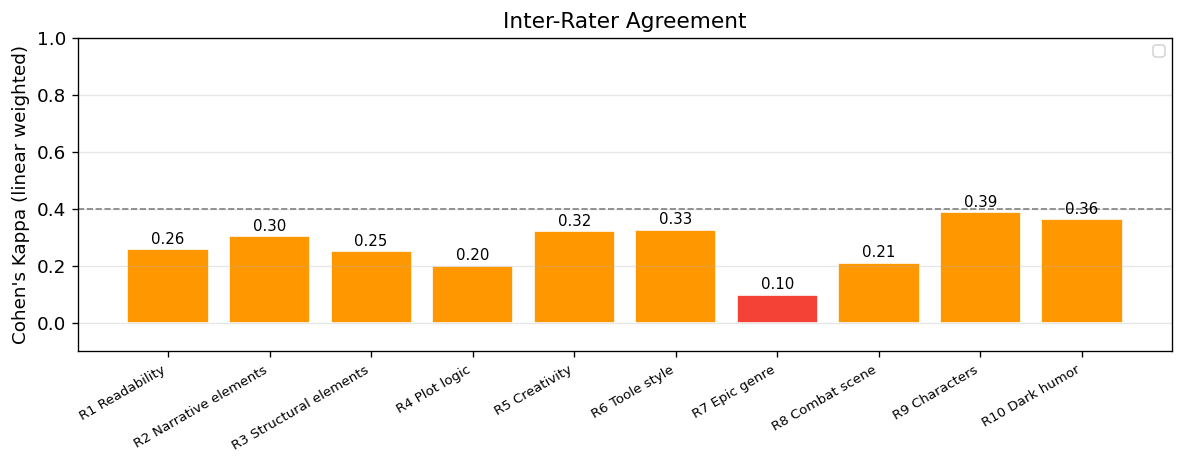


          Dimension  Kappa (linear)
        Readability        0.257469
 Narrative elements        0.303552
Structural elements        0.251936
         Plot logic        0.200820
         Creativity        0.320665
        Toole style        0.326021
         Epic genre        0.098048
       Combat scene        0.210772
         Characters        0.387842
         Dark humor        0.362388


<Figure size 768x576 with 0 Axes>

In [33]:
from sklearn.metrics import cohen_kappa_score

r1 = df[df['rater'] == 1].set_index('story_id')
r2 = df[df['rater'] == 2].set_index('story_id')

# Compute Cohen's kappa for each rubric dimension
kappas = {}
for dim in RUBRIC_SHORT:
    # Round scores to nearest integer for kappa calculation
    y1 = r1[dim].round().astype(int)
    y2 = r2[dim].round().astype(int)

    # Align on common index
    common = y1.index.intersection(y2.index)

    # Compute Cohen's kappa with linear weights
    try:
        k = cohen_kappa_score(y1.loc[common], y2.loc[common], weights='linear')
    except Exception:
        k = np.nan
    kappas[dim] = k

kappa_df = pd.DataFrame({'Dimension': RUBRIC_LABELS, 'Kappa (linear)': list(kappas.values())})

# Plot Cohen's kappa values
fig, ax = plt.subplots(figsize=(10, 4))
colors_k = ['#4CAF50' if k >= 0.4 else '#FF9800' if k >= 0.2 else '#F44336' for k in kappas.values()]
bars = ax.bar(RUBRIC_SHORT, kappas.values(), color=colors_k, edgecolor='white')
for bar, k in zip(bars, kappas.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{k:.2f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.4, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel("Cohen's Kappa (linear weighted)")
ax.set_title('Inter-Rater Agreement')
ax.set_ylim(-0.1, 1.0)
ax.set_xticklabels([f'R{i} {l}' for i, l in enumerate(RUBRIC_LABELS, 1)], fontsize=8, rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('figures/data_description/oneprompt_cohen_kappa.png', dpi=300, bbox_inches='tight')
print()
print(kappa_df.to_string(index=False))

## Overall ranking

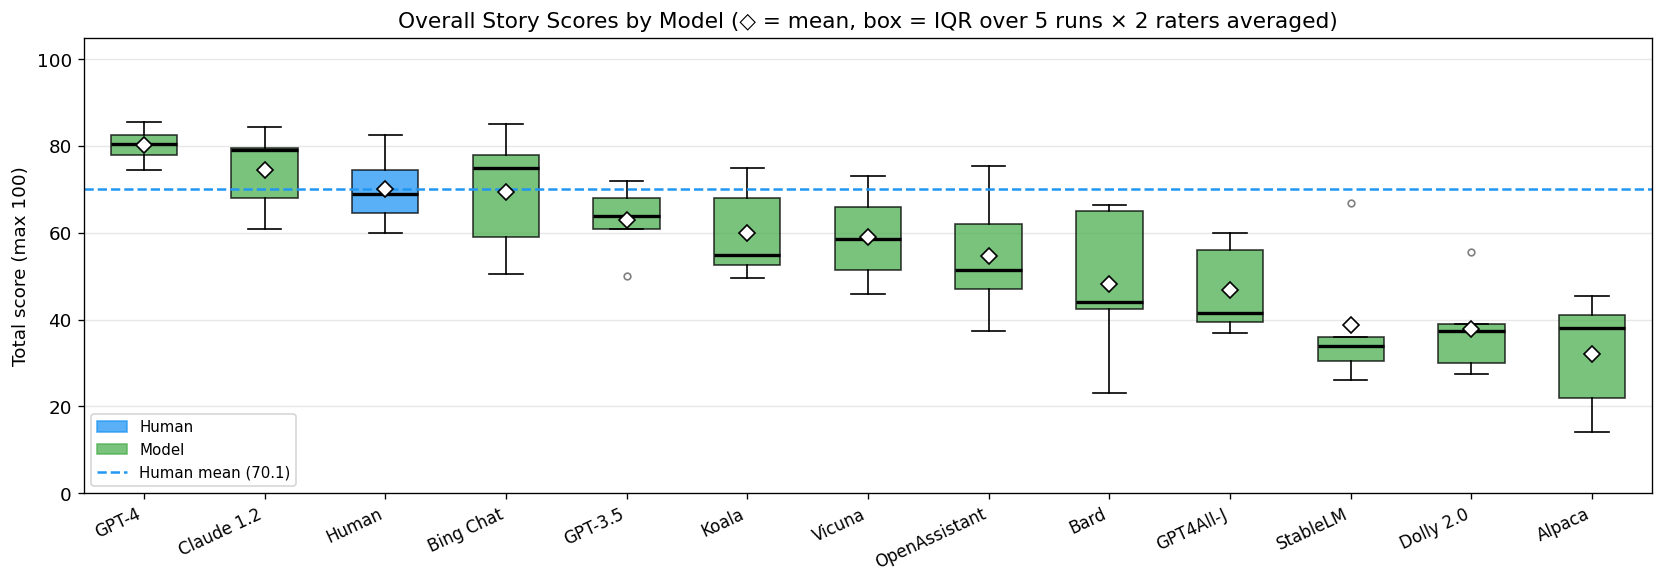

In [32]:
model_order = df_model['model'].tolist()
type_colors = {'Human': '#2196F3', 'Model': '#4CAF50'}

fig, ax = plt.subplots(figsize=(14, 5))

# Boxplot of total scores by model
bp_data = [df_story[df_story['model'] == m]['total'].values for m in model_order]
bp = ax.boxplot(bp_data, patch_artist=True, widths=0.55,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.5))

# Color boxes by type
for patch, model in zip(bp['boxes'], model_order):
    mtype = df_model.loc[df_model['model'] == model, 'type'].values[0]
    patch.set_facecolor(type_colors[mtype])
    patch.set_alpha(0.75)

# Mean dots
for i, m in enumerate(model_order, 1):
    mean_val = df_story[df_story['model'] == m]['total'].mean()
    ax.plot(i, mean_val, 'D', color='white', markeredgecolor='black',
            markersize=7, zorder=5)

human_mean = df_story[df_story['model'] == 'Human']['total'].mean()
ax.axhline(human_mean, color='#2196F3', linestyle='--', linewidth=1.5,
           label=f'Human mean ({human_mean:.1f})')

ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(model_order, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Total score (max 100)')
ax.set_title('Overall Story Scores by Model (◇ = mean, box = IQR over 5 runs × 2 raters averaged)')
ax.set_ylim(0, 105)

legend_patches = [mpatches.Patch(color=c, alpha=0.75, label=l) for l, c in type_colors.items()]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0], color='#2196F3', linestyle='--',
           label=f'Human mean ({human_mean:.1f})')], loc='lower left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/data_description/oneprompt_total_scores.png', dpi=300, bbox_inches='tight')
plt.show()

## Mean scores across all dimensions

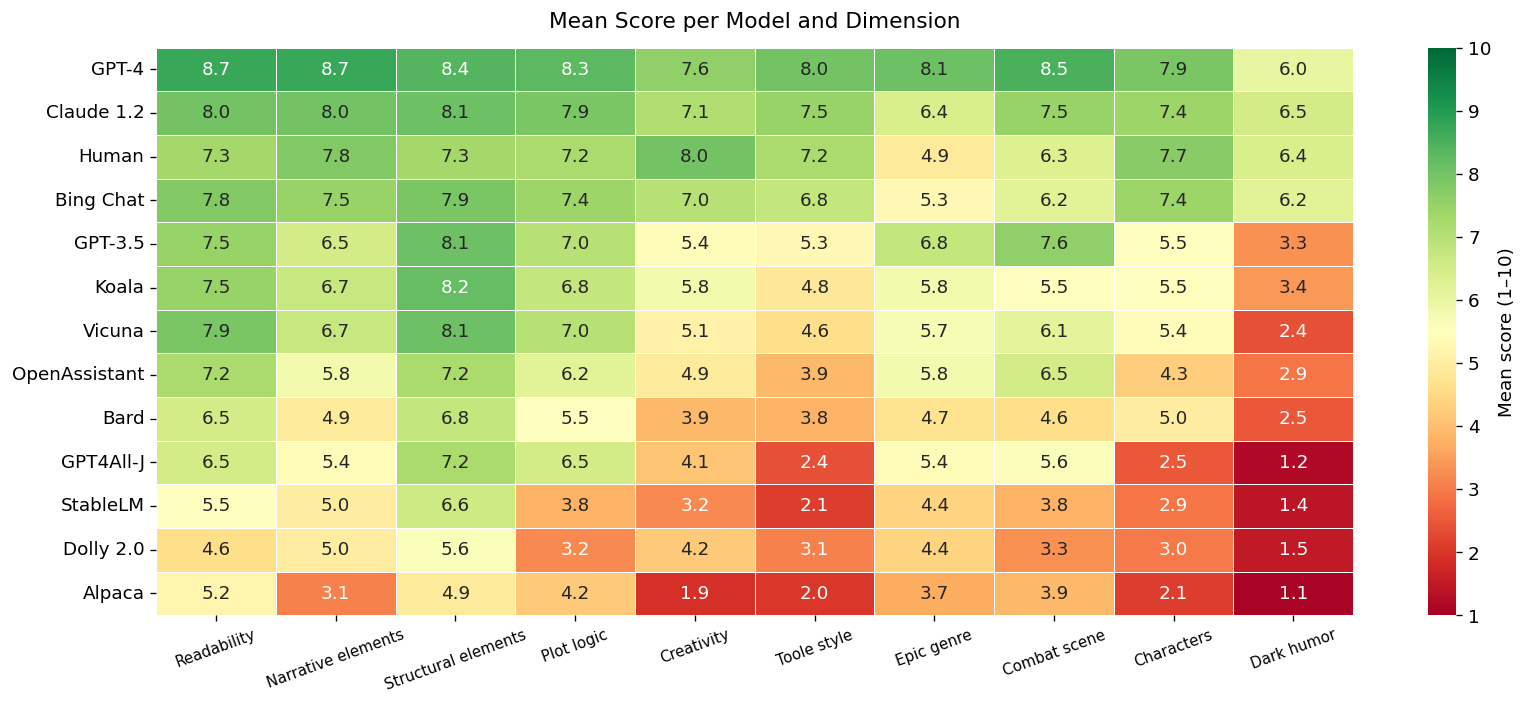

In [35]:
pivot = df_story.groupby('model')[RUBRIC_SHORT].mean().loc[model_order]
pivot.columns = RUBRIC_LABELS

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=1, vmax=10,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Mean score (1–10)'})
ax.set_title('Mean Score per Model and Dimension', pad=12)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=9, rotation=20)
plt.tight_layout()
plt.savefig('figures/data_description/oneprompt_mean_scores_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Within-model variability across 5 runs

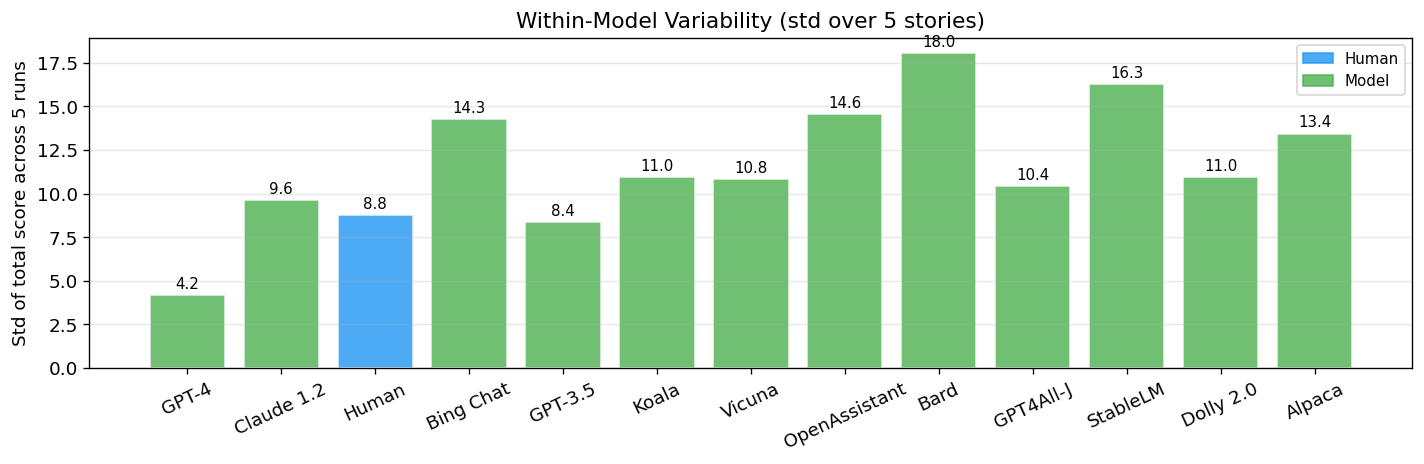

<Figure size 768x576 with 0 Axes>

In [37]:
# Compute standard deviation of total scores across 5 runs for each model
run_std = df_story.groupby('model')['total'].std().reindex(model_order)

bar_colors = [type_colors[df_model.loc[df_model['model']==m,'type'].values[0]]
              for m in model_order]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(model_order, run_std.values, color=bar_colors, alpha=0.8, edgecolor='white')
for bar, v in zip(bars, run_std.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{v:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Std of total score across 5 runs')
ax.set_title('Within-Model Variability (std over 5 stories)')
ax.tick_params(axis='x', rotation=25)
legend_patches = [mpatches.Patch(color=c, alpha=0.8, label=l) for l, c in type_colors.items()]
ax.legend(handles=legend_patches, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('figures/data_description/oneprompt_within_model_variability.png', dpi=300, bbox_inches='tight')

## Rater disagreement per story

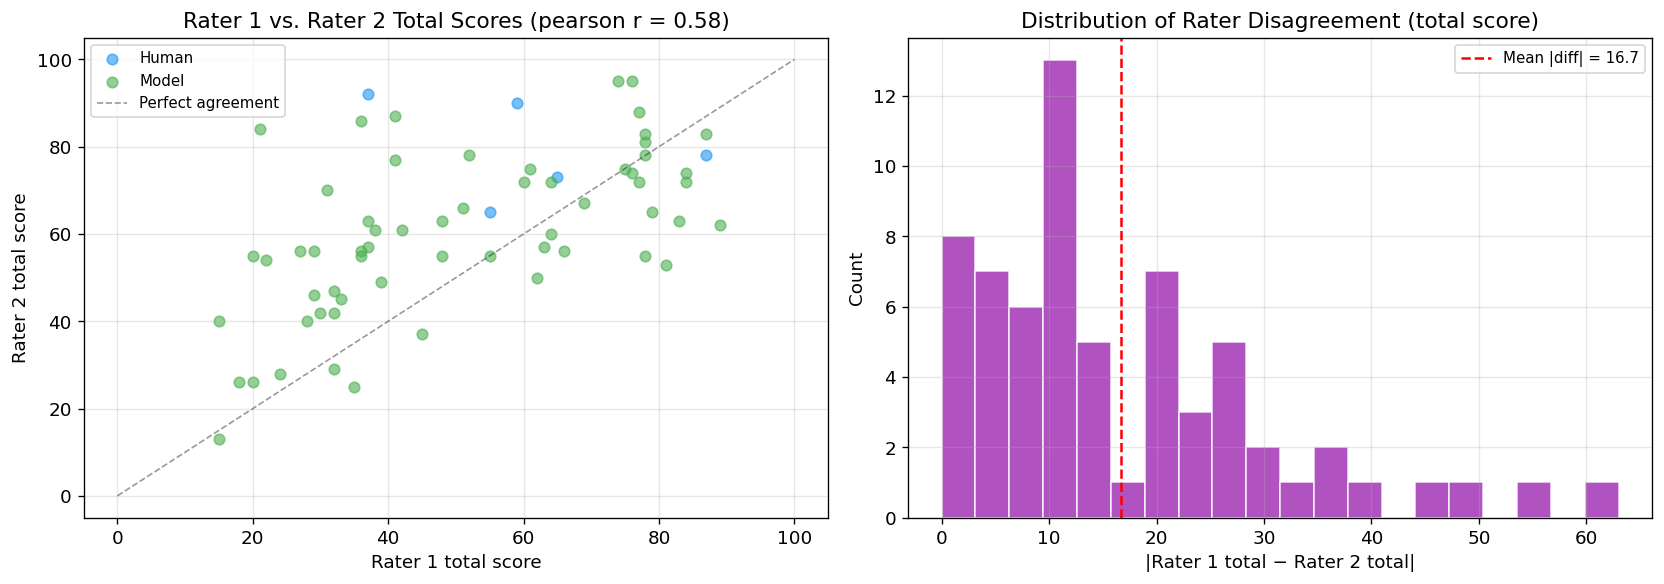

Mean absolute disagreement: 16.7 points
Max disagreement: 63 points
Stories with |diff| > 30: 9


In [40]:
r1_totals = df[df['rater']==1].set_index('story_id')['total']
r2_totals = df[df['rater']==2].set_index('story_id')['total']
common = r1_totals.index.intersection(r2_totals.index)

# DataFrame to analyze differences between raters
diff_df = pd.DataFrame({
    'story_id': common,
    'rater1': r1_totals.loc[common].values,
    'rater2': r2_totals.loc[common].values,
})
diff_df['abs_diff'] = (diff_df['rater1'] - diff_df['rater2']).abs()
# Add model info
model_map = df[df['rater']==1].set_index('story_id')['model']
diff_df['model'] = diff_df['story_id'].map(model_map)
diff_df['type']  = diff_df['model'].apply(source_type)
diff_df = diff_df.sort_values('abs_diff', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter rater1 vs rater2
ax = axes[0]
for mtype, color in type_colors.items():
    mask = diff_df['type'] == mtype
    ax.scatter(diff_df.loc[mask,'rater1'], diff_df.loc[mask,'rater2'],
               alpha=0.6, s=40, color=color, label=mtype)
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, alpha=0.4, label='Perfect agreement')
r, p = stats.pearsonr(diff_df['rater1'], diff_df['rater2'])
ax.set_xlabel('Rater 1 total score')
ax.set_ylabel('Rater 2 total score')
ax.set_title(f'Rater 1 vs. Rater 2 Total Scores (pearson r = {r:.2f})')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: distribution of |disagreement|
ax2 = axes[1]
ax2.hist(diff_df['abs_diff'], bins=20, color='#9C27B0', edgecolor='white', alpha=0.8)
ax2.axvline(diff_df['abs_diff'].mean(), color='red', linestyle='--',
            label=f'Mean |diff| = {diff_df["abs_diff"].mean():.1f}')
ax2.set_xlabel('|Rater 1 total − Rater 2 total|')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Rater Disagreement (total score)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig
plt.show()

print(f'Mean absolute disagreement: {diff_df["abs_diff"].mean():.1f} points')
print(f'Max disagreement: {diff_df["abs_diff"].max():.0f} points')
print(f'Stories with |diff| > 30: {(diff_df["abs_diff"] > 30).sum()}')

## Dimension correlations

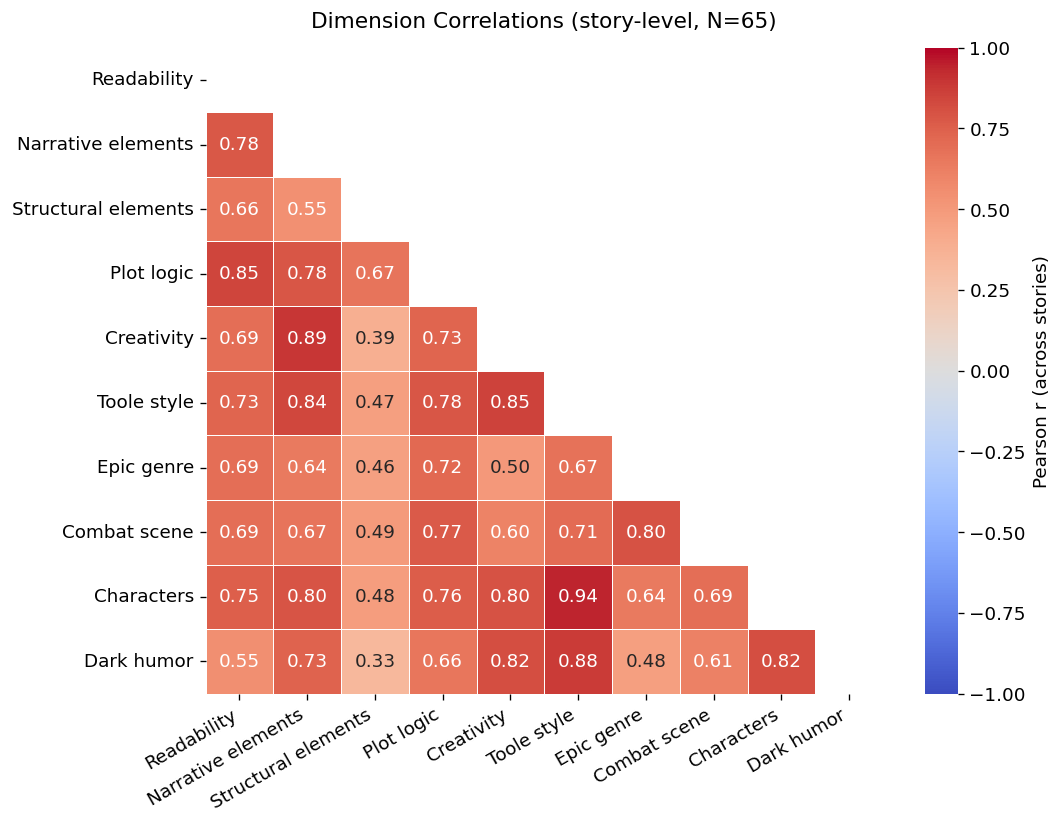

In [45]:
# Correlation heatmap of dimensions
corr = df_story[RUBRIC_SHORT].rename(columns=dict(zip(RUBRIC_SHORT, RUBRIC_LABELS))).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r (across stories)'})
ax.set_title('Dimension Correlations (story-level, N=65)', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/data_description/oneprompt_dimensions_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Summary statistics

In [47]:
summary = df_story.groupby(['model','type'])['total'].agg(['mean','std','min','max']).round(1)
summary.columns = ['Mean', 'Std', 'Min', 'Max']
summary['N stories'] = df_story.groupby(['model','type']).size()
summary = summary.sort_values('Mean', ascending=False)
summary['Rank'] = range(1, len(summary)+1)
display(summary[['Rank','N stories','Mean','Std','Min','Max']].style
        .background_gradient(subset=['Mean'], cmap='RdYlGn')
        .set_caption('Story-level totals per model (mean of 2 raters, 5 stories each)'))

summary[['Rank','N stories','Mean','Std','Min','Max']].to_csv('figures/data_description/oneprompt_summary_table.csv')

,,Rank,N stories,Mean,Std,Min,Max
model,type,,,,,,
GPT-4,Model,1,5,80.200000,4.200000,74.500000,85.500000
Claude 1.2,Model,2,5,74.400000,9.600000,61.000000,84.500000
Human,Human,3,5,70.100000,8.800000,60.000000,82.500000
Bing Chat,Model,4,5,69.500000,14.300000,50.500000,85.000000
GPT-3.5,Model,5,5,63.000000,8.400000,50.000000,72.000000
Koala,Model,6,5,60.000000,11.000000,49.500000,75.000000
Vicuna,Model,7,5,59.000000,10.800000,46.000000,73.000000
OpenAssistant,Model,8,5,54.700000,14.600000,37.500000,75.500000
Bard,Model,9,5,48.200000,18.000000,23.000000,66.500000
